# 08 · Model comparison: what is really different, and why

Steps 5 to 8 produced thirteen models whose scores are often within one or two percent of each other. This notebook asks three questions:

1. **Can several models do better together?** Forecast combinations.
2. **Are the differences real or due to chance?** Diebold-Mariano tests and the Model Confidence Set.
3. **Was the comparison fair?** Giving HAR-X the one piece of information it lacked.

**Run first** (from the project root, a few minutes):
```bash
python -m src.data.setup_db                # adds the result tables
python -m src.evaluation.run_comparison
```

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

from src.db import get_engine
from src.viz import AQUA, BLUE, GRID, INK, INK_2, MUTED, ORANGE, SURFACE, save, set_style

set_style()
engine = get_engine()
pd.set_option("display.width", 220)
pd.set_option("display.float_format", "{:,.3f}".format)

LABELS = {"naive": "Naive (last value)", "monthly_average": "Monthly average", "historical_mean": "Historical mean",
          "ewma": "EWMA of range-based variance", "riskmetrics": "RiskMetrics (EWMA of squared returns)",
          "garch": "GARCH(1,1)", "gjr_garch": "GJR-GARCH", "har": "HAR", "har_x": "HAR-X",
          "lgbm": "LightGBM", "lgbm_hybrid": "HAR-X + LightGBM", "lstm": "LSTM", "transformer": "Transformer",
          "ensemble_mean": "Ensemble (mean of 5)", "ensemble_median": "Ensemble (median of 5)"}
FAMILIES = {"ensemble": ("Combinations (Step 9)", INK), "deep_learning": ("Deep learning", AQUA),
            "machine_learning": ("Machine learning", ORANGE), "econometric": ("Econometric models", BLUE),
            "baseline": ("Baselines", MUTED)}
SHORT = {**LABELS, "ewma": "EWMA", "riskmetrics": "RiskMetrics", "naive": "Naive", "garch": "GARCH",
         "ensemble_mean": "Ensemble mean", "ensemble_median": "Ensemble median"}
HORIZON_LABELS = {1: "1 day", 5: "5 days", 22: "22 days"}
DIVERGING = LinearSegmentedColormap.from_list("better_worse", [BLUE, "#e9e8e4", ORANGE])   # blue = better, orange = worse

overall = pd.read_sql("SELECT * FROM model_scores_overall", engine)
overall["model_label"] = overall["model"].map(LABELS)
ranking = overall[overall["horizon"] == 5].sort_values("qlike")["model"].tolist()            # order used in the charts

## 1. Forecast combinations

The five models that use the full feature set (HAR-X, LightGBM, the hybrid, the LSTM and the Transformer) make different errors: Steps 7 and 8 showed that each has its own bad years. A classic remedy is to **combine** them:

* **Ensemble (mean):** the average of the five variance forecasts;
* **Ensemble (median):** their median, which ignores the most extreme forecast on each side.

The members were fixed in advance (all the models with the full feature set), not selected on their test results, and the weights are equal: nothing is estimated on the test period.

In [2]:
def table(metric):
    t = overall.pivot(index="model_label", columns="horizon", values=metric).rename(columns=HORIZON_LABELS)
    return t.sort_values("5 days")

print(f"Forecasts per model and horizon: about {overall['n_forecasts'].median():,.0f}")
print("\nQLIKE (lower is better)")
display(table("qlike").head(8))
print("MAE in annualised volatility points")
display(table("mae_vol").head(8))

reference = overall[overall["model"] == "har_x"].set_index("horizon")["qlike"]
ensembles = overall[overall["family"] == "ensemble"].pivot(index="model_label", columns="horizon", values="qlike")
print("QLIKE of the combinations relative to HAR-X")
display((ensembles / reference - 1).rename(columns=HORIZON_LABELS).map("{:+.1%}".format))

Forecasts per model and horizon: about 306,931

QLIKE (lower is better)


horizon,1 day,5 days,22 days
model_label,,,
Ensemble (mean of 5),0.369,0.216,0.202
Ensemble (median of 5),0.370,0.217,0.201
HAR-X + LightGBM,0.371,0.220,0.214
HAR-X,0.378,0.220,0.199
LSTM,0.373,0.221,0.206
LightGBM,0.372,0.221,0.216
Transformer,0.372,0.222,0.212
HAR,0.400,0.242,0.212


MAE in annualised volatility points


horizon,1 day,5 days,22 days
model_label,,,
Transformer,7.964,6.302,6.156
Ensemble (median of 5),7.936,6.314,6.213
Ensemble (mean of 5),7.967,6.337,6.243
HAR-X + LightGBM,7.914,6.399,6.569
LightGBM,7.928,6.402,6.543
HAR-X,8.126,6.409,6.236
LSTM,8.151,6.480,6.288
HAR,8.641,7.007,6.742


QLIKE of the combinations relative to HAR-X


horizon,1 day,5 days,22 days
model_label,,,
Ensemble (mean of 5),-2.4%,-1.8%,+1.5%
Ensemble (median of 5),-2.1%,-1.3%,+1.4%


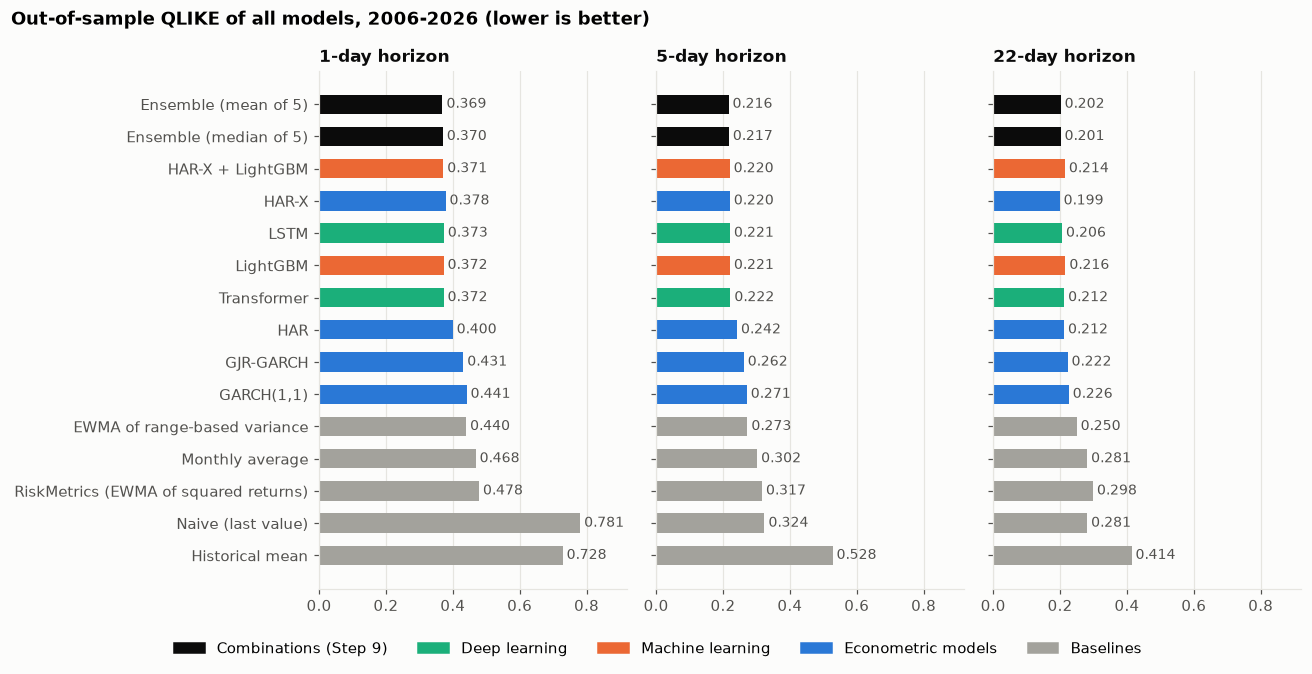

In [3]:
family = overall.drop_duplicates("model_label").set_index("model_label")["family"]
fig, axes = plt.subplots(1, 3, figsize=(12, 6), sharex=True)
order = table("qlike").index[::-1]
for ax, h in zip(axes, [1, 5, 22]):
    scores = overall[overall["horizon"] == h].set_index("model_label").loc[order, "qlike"]
    ax.barh(scores.index, scores.values, color=[FAMILIES[family[m]][1] for m in scores.index], height=0.6)
    for y, v in enumerate(scores.values):
        ax.text(v + 0.012, y, f"{v:.3f}", va="center", color=INK_2, fontsize=9)
    ax.set_title(f"{h}-day horizon", fontsize=11)
    ax.grid(axis="y", visible=False)
    if h != 1:
        ax.set_yticklabels([])
axes[0].set_xlim(0, overall["qlike"].max() * 1.18)
handles = [plt.Rectangle((0, 0), 1, 1, color=color) for _, color in FAMILIES.values()]
fig.legend(handles, [label for label, _ in FAMILIES.values()], loc="lower center", ncols=5, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Out-of-sample QLIKE of all models, 2006-2026 (lower is better)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(rect=(0, 0.04, 1, 1))
save(fig, "09_model_scores")
plt.show()

**Reading the results.**

* **Combining the models gives the best forecasts at 1 and 5 days.** The average of the five models has a QLIKE 2.4% below HAR-X at 1 day and 1.8% below at 5 days, better than any single model. No individual model had managed to beat HAR-X at 5 days.
* **At 22 days HAR-X alone remains the best**: the combination is 1.5% worse, because four of its five members are worse than HAR-X at that horizon.
* **Mean or median makes little difference.** The mean is slightly ahead on QLIKE, the median on the mean absolute error.

Why does it work? The five models have similar accuracy but make partly different errors: the trees are too low in 2008, the LSTM fails in 2009, the Transformer in 2020. Averaging dilutes each model's own mistakes while keeping what they have in common.

### Does the choice of members matter?

The hybrid is HAR-X multiplied by a LightGBM correction, so its forecast is close to those of two other members. With five members, the "HAR-X and trees" view of the world therefore weighs more than the two neural networks. Is the gain of the combination a consequence of this particular choice?

**Robustness check, added after the main results were known.** Two smaller combinations are compared with the main one:

* **4 members, without the hybrid:** HAR-X, LightGBM, LSTM, Transformer;
* **3 members, one per family:** HAR-X (econometric), LightGBM (machine learning), LSTM (deep learning).

They are not added to the list of models and do not replace the main combination, which was fixed before looking at the test results. Each is tested against HAR-X and against the main combination with a Diebold-Mariano test (explained in section 2); a p-value below 0.05 means that the difference is unlikely to be due to chance.

In [4]:
variants = pd.read_sql("SELECT * FROM ensemble_variants ORDER BY n_members DESC, horizon", engine)
order = variants.drop_duplicates("variant")["variant"].tolist()

def by_horizon(column, fmt):
    return variants.pivot(index="variant", columns="horizon", values=column).loc[order].rename(columns=HORIZON_LABELS).map(fmt.format)

def with_p_value(column, p_column):
    text = variants[column].map("{:+.2%}".format) + variants[p_column].map(lambda p: "" if pd.isna(p) else f"  (p = {p:.3f})")
    return (variants.assign(text=text).pivot(index="variant", columns="horizon", values="text")
            .loc[order].rename(columns=HORIZON_LABELS))

print("QLIKE (lower is better)")
display(by_horizon("qlike", "{:.4f}"))
print("QLIKE relative to HAR-X (negative = better than HAR-X), with the p-value of the test")
display(with_p_value("qlike_vs_harx", "p_vs_harx"))
print("QLIKE relative to the main combination of 5 (negative = better than the main one)")
display(with_p_value("qlike_vs_main", "p_vs_main").iloc[1:])

QLIKE (lower is better)


horizon,1 day,5 days,22 days
variant,,,
5 members (main),0.3690,0.2164,0.2015
"4 members, without the hybrid",0.3693,0.2163,0.2006
"3 members, one per family",0.3701,0.2169,0.2007


QLIKE relative to HAR-X (negative = better than HAR-X), with the p-value of the test


horizon,1 day,5 days,22 days
variant,,,
5 members (main),-2.40% (p = 0.000),-1.77% (p = 0.001),+1.52% (p = 0.216)
"4 members, without the hybrid",-2.32% (p = 0.000),-1.84% (p = 0.002),+1.05% (p = 0.433)
"3 members, one per family",-2.10% (p = 0.000),-1.58% (p = 0.000),+1.11% (p = 0.277)


QLIKE relative to the main combination of 5 (negative = better than the main one)


horizon,1 day,5 days,22 days
variant,,,
"4 members, without the hybrid",+0.08% (p = 0.025),-0.07% (p = 0.465),-0.46% (p = 0.121)
"3 members, one per family",+0.30% (p = 0.027),+0.20% (p = 0.603),-0.40% (p = 0.428)


**Reading the check.** The conclusion does not depend on the choice of members.

* **All three combinations beat HAR-X by about the same margin**: 2.1 to 2.4% at 1 day and 1.6 to 1.8% at 5 days, significant in every case (p ≤ 0.002). At 22 days none is significantly different from HAR-X, as for the main combination.
* **Removing the hybrid changes almost nothing**: +0.08% at 1 day, -0.07% at 5 days, -0.46% at 22 days. Only the first difference is statistically detectable (p = 0.025), and it is thirty times smaller than the gain over HAR-X. The gain of the combination is therefore not produced by counting HAR-X and the trees twice.
* **Three members are enough to get most of the benefit**: one model per family is 0.2 to 0.3% behind the five at 1 and 5 days.
* **At 22 days the smaller combinations are slightly better** (-0.4 to -0.5%, not significant): the hybrid is one of the weakest models at that horizon, and removing it helps a little.

The main combination stays the one reported in the rest of the notebook, because it was fixed before the results were known. Picking the best variant at each horizon afterwards would be choosing a model on the test data.

## 2. Are the differences real?

A lower average loss does not prove that a model is better: with noisy data, a difference of one percent can easily be due to chance.

**The Diebold-Mariano test** compares two models. For each day it takes the difference between their losses (averaged over all series, because stocks move together and 59 losses of the same day are not 59 independent observations), and tests whether the average difference is zero. The variance is corrected for the fact that losses of consecutive days are correlated (Newey-West).

The **p-value** is the probability of observing a difference at least this large if the two models were in fact equally accurate. Below 0.05, the difference is conventionally called *significant*.

The table compares every model with **HAR-X**. A negative difference means that the model is better than HAR-X.

### Why HAR-X is the reference

Every model is compared with HAR-X rather than with a baseline or with the best model of the table. Four reasons:

1. **It is the best model without machine learning.** HAR-X beats the baselines, GARCH, GJR-GARCH and HAR at every horizon (Step 6). Beating a weak model proves little: against the naive forecast every model of this project looks excellent (the naive forecast has twice the QLIKE of HAR-X at 1 day). The question of this project is whether machine learning adds anything **to the best classical tool**.
2. **It starts from the same information as the advanced models.** LightGBM uses the features of HAR-X (plus the day of the week and a stock / index flag); the networks contain a HAR-X regression and add the last 22 days of raw data. The gap with HAR-X therefore measures what the **algorithm** adds, not extra data. Where an advanced model did have extra information (the stock / index flag), section 3 gives it to HAR-X too before drawing a conclusion.
3. **It is the standard benchmark of the field.** The HAR model (Corsi, 2009) is the usual reference in volatility forecasting.
4. **It is the cheap, transparent alternative.** Estimated in seconds, 18 readable coefficients. A model that needs hours of training and is harder to validate and to explain has to earn that cost by beating HAR-X.

Two remarks on what the reference does **not** do:

* **It does not change the ranking.** "−2.4% against HAR-X" divides the QLIKE of every model by the same number: the order is exactly the one of the raw QLIKE in section 1.
* **The conclusions do not depend on it.** The Model Confidence Set further below uses no reference model at all, and tells the same story: HAR-X is outside the set at 1 day, inside it at 5 and 22 days.

In [5]:
tests = pd.read_sql("SELECT * FROM model_tests", engine)

def stars(p):
    return "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else ""

versus = tests[tests["reference"] == "har_x"].merge(reference.rename("harx_qlike"), left_on="horizon", right_index=True)
versus["cell"] = [f"{d / q:+.1%}{stars(p):<3}  (p = {p:.3f})" for d, q, p in zip(versus["mean_loss_diff"], versus["harx_qlike"], versus["p_value"])]
shown = versus.pivot(index="model", columns="horizon", values="cell").rename(columns=HORIZON_LABELS)
shown = shown.loc[[m for m in ranking if m != "har_x"]].rename(index=LABELS)
print("QLIKE relative to HAR-X, with the p-value of the Diebold-Mariano test   (*** p < 0.01, ** p < 0.05, * p < 0.10)")
display(shown)

QLIKE relative to HAR-X, with the p-value of the Diebold-Mariano test   (*** p < 0.01, ** p < 0.05, * p < 0.10)


horizon,1 day,5 days,22 days
model,,,
Ensemble (mean of 5),-2.4%*** (p = 0.000),-1.8%*** (p = 0.001),+1.5% (p = 0.216)
Ensemble (median of 5),-2.1%*** (p = 0.000),-1.4%*** (p = 0.000),+1.4% (p = 0.170)
HAR-X + LightGBM,-1.9%*** (p = 0.000),-0.3% (p = 0.560),+8.1%*** (p = 0.000)
LSTM,-1.3%*** (p = 0.003),+0.2% (p = 0.845),+3.6%* (p = 0.063)
LightGBM,-1.6%*** (p = 0.000),+0.1% (p = 0.905),+8.7%*** (p = 0.000)
Transformer,-1.5%*** (p = 0.009),+0.7% (p = 0.718),+6.7%* (p = 0.096)
HAR,+5.6%*** (p = 0.000),+9.6%*** (p = 0.000),+6.6%** (p = 0.037)
GJR-GARCH,+14.0%*** (p = 0.000),+18.8%*** (p = 0.000),+12.0%*** (p = 0.003)
"GARCH(1,1)",+16.5%*** (p = 0.000),+22.8%*** (p = 0.000),+13.7%*** (p = 0.001)


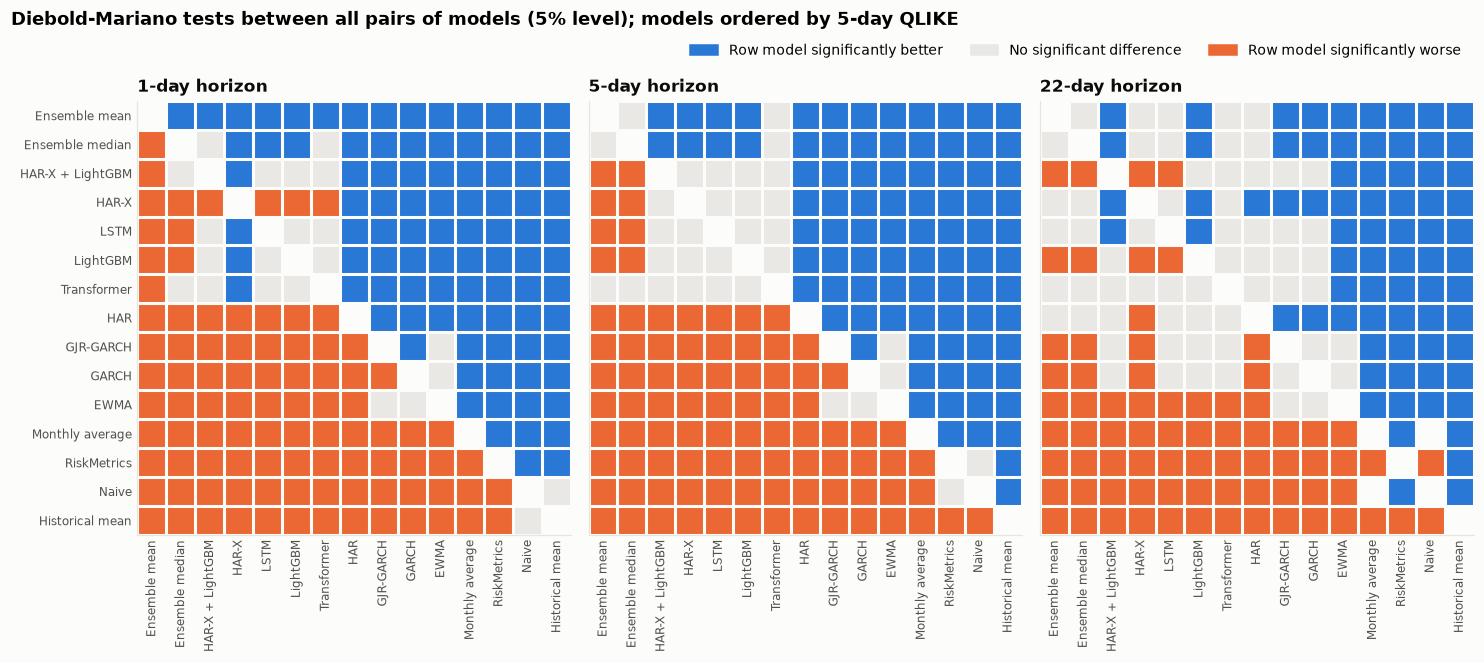

In [6]:
# Every model against every other one, at each horizon: is the row model better or worse than the column model?
def verdicts(horizon, level=0.05):
    t = tests[tests["horizon"] == horizon]
    stat = t.pivot(index="model", columns="reference", values="dm_stat").loc[ranking, ranking]
    p = t.pivot(index="model", columns="reference", values="p_value").loc[ranking, ranking]
    return np.where(p.to_numpy() >= level, 0, np.sign(stat.to_numpy()))        # -1 better, 0 no difference, +1 worse

fig, axes = plt.subplots(1, 3, figsize=(13.5, 6.2), sharey=True)
categories = ListedColormap([BLUE, "#e9e8e4", ORANGE])
labels = [SHORT[m] for m in ranking]
for ax, horizon in zip(axes, [1, 5, 22]):
    grid = verdicts(horizon)
    grid[np.arange(len(ranking)), np.arange(len(ranking))] = np.nan
    ax.imshow(grid, cmap=categories, vmin=-1, vmax=1)
    ax.set_xticks(range(len(ranking)), labels, rotation=90, fontsize=8)
    ax.set_yticks(range(len(ranking)), labels, fontsize=8)
    ax.set_xticks(np.arange(-0.5, len(ranking)), minor=True)
    ax.set_yticks(np.arange(-0.5, len(ranking)), minor=True)
    ax.grid(False)
    ax.grid(which="minor", color=SURFACE, linewidth=2)
    ax.tick_params(which="both", length=0)
    ax.set_title(f"{horizon}-day horizon", fontsize=11)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in (BLUE, "#e9e8e4", ORANGE)]
fig.legend(handles, ["Row model significantly better", "No significant difference", "Row model significantly worse"],
           loc="upper right", ncols=3, bbox_to_anchor=(0.995, 0.95), fontsize=9)
fig.suptitle("Diebold-Mariano tests between all pairs of models (5% level); models ordered by 5-day QLIKE",
             x=0.01, ha="left", fontweight="bold")
fig.subplots_adjust(left=0.095, right=0.995, bottom=0.2, top=0.86, wspace=0.04)
save(fig, "09_pairwise_tests")
plt.show()

**The Model Confidence Set** answers the question for all models at once. Comparing fifteen models two by two means 105 tests per horizon, and with that many tests some will look significant by chance alone. The Model Confidence Set removes the models one by one, the worst first, for as long as the remaining ones can be told apart. What is left is the set of models that **cannot be distinguished from the best** at the chosen confidence level (here 90%).

In [7]:
mcs = pd.read_sql("SELECT * FROM model_confidence_set", engine)
p_values = mcs.pivot(index="model", columns="horizon", values="mcs_p_value").loc[ranking]
members = p_values >= 0.10                                   # in the 90% confidence set
shown = pd.DataFrame({HORIZON_LABELS[h]: [("in the set" if keep else "-") + f"  (p = {p:.2f})" for keep, p in zip(members[h], p_values[h])]
                      for h in (1, 5, 22)}, index=[LABELS[m] for m in ranking])
display(shown)
print("Models in the 90% confidence set:", {HORIZON_LABELS[h]: int(members[h].sum()) for h in (1, 5, 22)}, "out of", len(ranking))

,1 day,5 days,22 days
Ensemble (mean of 5),in the set (p = 1.00),in the set (p = 1.00),in the set (p = 0.70)
Ensemble (median of 5),in the set (p = 0.34),in the set (p = 0.79),in the set (p = 0.70)
HAR-X + LightGBM,in the set (p = 0.34),in the set (p = 0.79),in the set (p = 0.17)
HAR-X,- (p = 0.00),in the set (p = 0.79),in the set (p = 1.00)
LSTM,- (p = 0.07),in the set (p = 0.79),in the set (p = 0.70)
LightGBM,in the set (p = 0.34),in the set (p = 0.79),in the set (p = 0.14)
Transformer,in the set (p = 0.34),in the set (p = 0.79),in the set (p = 0.70)
HAR,- (p = 0.00),- (p = 0.00),in the set (p = 0.70)
GJR-GARCH,- (p = 0.00),- (p = 0.00),in the set (p = 0.19)
"GARCH(1,1)",- (p = 0.00),- (p = 0.00),in the set (p = 0.14)


Models in the 90% confidence set: {'1 day': 5, '5 days': 7, '22 days': 10} out of 15


**Reading the tests.** The answer depends on the horizon.

* **1 day: the gains are real.** The five advanced models and the two combinations are all significantly better than HAR-X (p < 0.01), by 1.3 to 2.4%. HAR-X is not in the confidence set at that horizon: the more flexible models do extract something that the linear regression misses in the very short term.
* **5 days: the single models cannot be told apart.** None of LightGBM, the hybrid, the LSTM or the Transformer differs significantly from HAR-X (p-values between 0.56 and 0.91). Only the two combinations are significantly better (p < 0.01). The confidence set contains exactly the seven models that use the full feature set.
* **22 days: HAR-X is best, but few differences are significant.** The two LightGBM models are significantly worse than HAR-X (+8%, p < 0.001). The LSTM (+3.6%) and the Transformer (+6.7%) are not, at the 5% level. The confidence set keeps ten models, including GARCH: with overlapping 22-day targets there are few independent observations, and the tests have little power to separate models.
* **What is never in doubt:** HAR-X is significantly better than the plain HAR at every horizon, and every baseline is rejected at 1 and 5 days. The features of Step 4 and the estimation of the weights are not a matter of chance.

Two practical lessons. A difference of 1% in a table means nothing without a test: at 5 days the hybrid is "0.3% better" than HAR-X with a p-value of 0.56. And significance is not size: at 1 day the gains are statistically certain, but they remain around 2%.

## 3. Equal information: the stock / index flag

The tree and neural models of Steps 7 and 8 receive a feature that HAR-X does not: `is_index`. They also removed the bias of HAR-X on indices. Was that due to their non-linearity, or simply to this extra piece of information? Giving `is_index` to HAR-X answers the question.

In [9]:
experiments = pd.read_sql("SELECT * FROM experiment_scores", engine)
by_type = experiments[(experiments["experiment"] == "ablation") & experiments["segment"].isin(["stock", "index"])
                      & experiments["variant"].isin(["HAR-X", "HAR-X + is_index"]) & (experiments["horizon"] == 5)]
complete = " AND ".join(f"f.{m} IS NOT NULL" for m in overall["model"].unique())
stored = pd.concat([pd.read_sql(f"""
    SELECT '{LABELS[m]}' AS variant, u.asset_type AS segment,
           avg(exp(x.target_5d) / f.{m} - ln(exp(x.target_5d) / f.{m}) - 1) AS qlike, avg(exp(x.target_5d) / f.{m}) AS bias
    FROM forecasts f JOIN features x USING (ticker, date) JOIN universe u USING (ticker)
    WHERE f.horizon = 5 AND x.target_5d IS NOT NULL AND {complete} GROUP BY 2""", engine) for m in ("lgbm_hybrid", "lstm")])
flag = pd.concat([by_type[["variant", "segment", "qlike", "bias"]], stored], ignore_index=True)
shown = flag.pivot(index="variant", columns="segment", values=["qlike", "bias"]).loc[["HAR-X", "HAR-X + is_index", "HAR-X + LightGBM", "LSTM"]]
shown.columns = [f"{'QLIKE' if a == 'qlike' else 'actual / forecast'}, {'indices' if b == 'index' else 'stocks'}" for a, b in shown.columns]
print("5-day horizon (actual / forecast: 1 = right on average, below 1 = forecasts too high)")
display(shown)
overall_flag = q.loc[["HAR-X", "HAR-X + is_index"]].rename(columns=HORIZON_LABELS)
print("QLIKE on all series:")
display(overall_flag)

5-day horizon (actual / forecast: 1 = right on average, below 1 = forecasts too high)


,"QLIKE, indices","QLIKE, stocks","actual / forecast, indices","actual / forecast, stocks"
variant,,,,
HAR-X,0.179,0.228,0.945,1.061
HAR-X + is_index,0.178,0.227,1.001,1.045
HAR-X + LightGBM,0.174,0.228,1.040,1.063
LSTM,0.177,0.228,1.054,1.058


QLIKE on all series:


horizon,1 day,5 days,22 days
variant,,,
HAR-X,0.378,0.220,0.199
HAR-X + is_index,0.378,0.220,0.198


**The flag alone removes the bias.** With `is_index`, the linear HAR-X goes from forecasts 5% too high for indices (0.945) to forecasts that are right on average (1.001). The removal of the bias by LightGBM and by the networks in Steps 7 and 8 was therefore due to the **extra piece of information**, not to their non-linearity.

The effect on accuracy is small: QLIKE on indices improves from 0.179 to 0.178, and the overall score is almost unchanged. The hybrid remains a little better on indices (0.174), which is the part that can be attributed to non-linearity.

This is a reminder to compare models on equal information. Had the flag been left out of this check, a share of the tree and neural models' results would have been credited to their architecture by mistake.

## 4. Stability over time

One row per model, one column per test year: the 5-day QLIKE relative to HAR-X. Blue means better than HAR-X that year, orange worse; the scale is capped at ±15%.

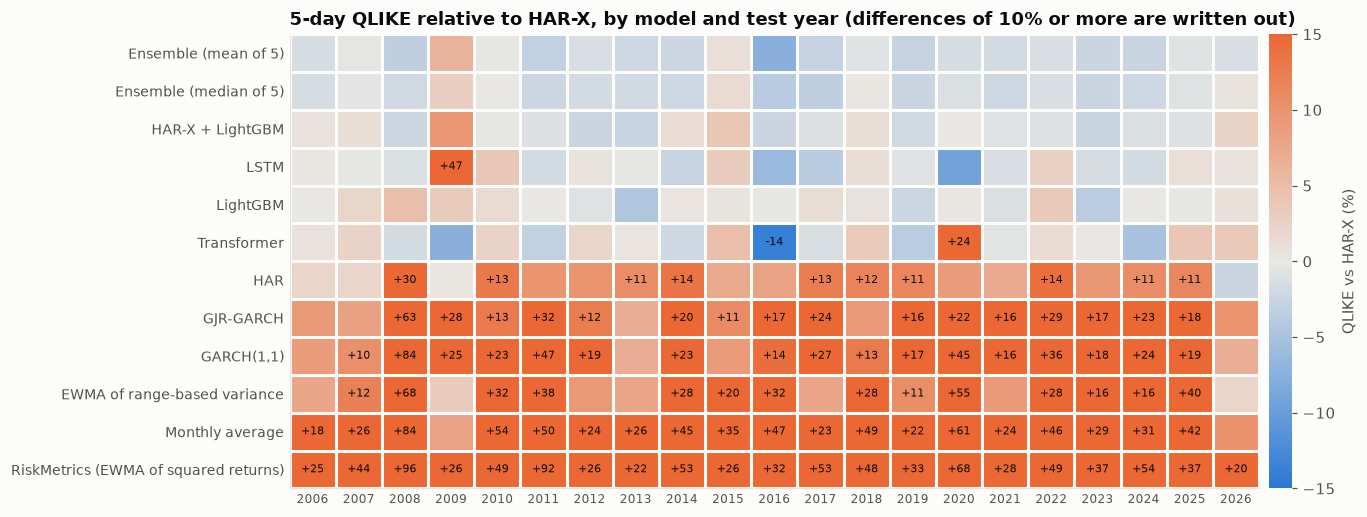

,years better than HAR-X,worst year vs HAR-X (%)
model,,
Ensemble (mean of 5),19,6.300
Ensemble (median of 5),16,3.000
HAR-X + LightGBM,14,9.600
LSTM,12,46.600
LightGBM,7,4.700
Transformer,9,23.700
HAR,1,29.700
GJR-GARCH,0,62.600
"GARCH(1,1)",0,84.200


In [11]:
by_year = pd.read_sql("SELECT model, test_year, sum(qlike * n) / sum(n) AS qlike FROM model_scores WHERE horizon = 5 GROUP BY 1, 2",
                      engine).pivot(index="model", columns="test_year", values="qlike")
rows = [m for m in ranking if m not in ("har_x", "historical_mean", "naive")]
relative = (by_year.loc[rows] / by_year.loc["har_x"] - 1) * 100

fig, ax = plt.subplots(figsize=(12.5, 4.8))
image = ax.imshow(relative.to_numpy(), cmap=DIVERGING, vmin=-15, vmax=15, aspect="auto")
ax.set_xticks(range(relative.shape[1]), relative.columns, fontsize=8)
ax.set_yticks(range(len(rows)), [LABELS[m] for m in rows], fontsize=9)
ax.set_xticks(np.arange(-0.5, relative.shape[1]), minor=True)
ax.set_yticks(np.arange(-0.5, len(rows)), minor=True)
ax.grid(False)
ax.grid(which="minor", color=SURFACE, linewidth=2)
ax.tick_params(which="both", length=0)
for i in range(relative.shape[0]):
    for j in range(relative.shape[1]):
        value = relative.iat[i, j]
        if abs(value) >= 10:
            ax.text(j, i, f"{value:+.0f}", ha="center", va="center", fontsize=7, color=INK)
colorbar = fig.colorbar(image, ax=ax, pad=0.01, fraction=0.025)
colorbar.set_label("QLIKE vs HAR-X (%)")
colorbar.outline.set_visible(False)
ax.set_title("5-day QLIKE relative to HAR-X, by model and test year (differences of 10% or more are written out)")
fig.tight_layout()
save(fig, "09_by_year")
plt.show()

wins = (relative < 0).sum(axis=1).rename("years better than HAR-X")
worst = relative.max(axis=1).rename("worst year vs HAR-X (%)")
display(pd.concat([wins, worst.round(1)], axis=1).rename(index=LABELS))

**Reading the chart.**

* **The combination is the steadiest of the advanced models.** The average of the five models beats HAR-X in 19 test years out of 21, and its worst year is 6% behind (2009). The median is even safer in its worst year (3%).
* **Single models have blind spots**: the LSTM in 2009 (+47%), the Transformer in 2020 (+24%), the hybrid in 2009 (+10%). They are visible as isolated dark cells. Most of them fall in different years, which is why averaging works; 2009 is the exception, where two of the five members fail together, and it is also the combination's worst year.
* **The lower half of the chart is uniformly orange.** GARCH, EWMA and the other baselines are worse than HAR-X almost every year, often by 20% or more, and most of all in crisis years (2008, 2011, 2020). The gap between the simple and the advanced models is of another order than the differences among the advanced ones.

## Summary

**The final ranking** (QLIKE, lower is better):

| | 1 day | 5 days | 22 days |
|---|---|---|---|
| Best model | Ensemble mean (0.369) | Ensemble mean (0.216) | HAR-X (0.199) |
| HAR-X | 0.378 | 0.220 | 0.199 |
| Best baseline (EWMA) | 0.440 | 0.273 | 0.250 |

* **Two things separate good forecasts from poor ones, and both are settled beyond statistical doubt:** measuring volatility well (range-based variance) and using the right information (HAR-X against HAR, GARCH and the baselines).
* **The choice of the algorithm matters little.** At 5 days, a linear regression, gradient-boosted trees, an LSTM and a Transformer cannot be distinguished statistically. More complex models are significantly better only at 1 day, by about 2%, and worse at 22 days.
* **Combining models is the one reliable improvement:** significantly better than HAR-X at 1 and 5 days, and better in 19 years out of 21, because the models fail in different years. The gain does not depend on which members are chosen: with four or three of the five it is nearly the same.
* **Equal information before comparing:** the removal of the index bias by the tree and neural models came from one extra feature, which fixes the linear model just as well.

**Recommendation.** For 1 to 5 days, the average of the five models; for a month, HAR-X alone. If only one model can be maintained, HAR-X: it is within 2.4% of the best at every horizon, is estimated in seconds, has 18 coefficients that can be read, and has no bad year.

Next: Step 10 puts the forecasts to work in a Value-at-Risk backtest.